<a href="https://colab.research.google.com/github/peemoshi/ai-ml-internship/blob/main/week-2/2.2-cnn-image-classifier/cnn_cifar10_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loads the CIFAR-10 dataset (60,000 32×32 color images across 10 categories) and checks that a GPU is available for faster training. Pixel values are converted to tensors and normalized to roughly -1 to 1, which helps the network train more effectively. A few sample images are displayed to visually confirm the data loaded correctly.

Using device: cuda
Training images: 50000
Test images: 10000
Image shape: torch.Size([3, 32, 32])   Label: frog


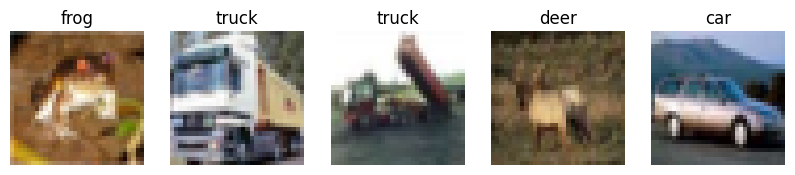

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))   # scale pixel values roughly to [-1, 1]
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("Training images:", len(train_set))
print("Test images:", len(test_set))

# Inspect one sample image
img, label = train_set[0]
print("Image shape:", img.shape, "  Label:", classes[label])

# Show a few sample images
fig, axes = plt.subplots(1, 5, figsize=(10,3))
for i in range(5):
    img, label = train_set[i]
    img_display = img / 2 + 0.5   # undo the normalization for display
    axes[i].imshow(np.transpose(img_display.numpy(), (1,2,0)))
    axes[i].set_title(classes[label])
    axes[i].axis('off')
plt.show()

Confirms the dataset is perfectly balanced with exactly 5,000 images per class, so accuracy alone will be a fair metric here, unlike the classification task.

In [3]:
import numpy as np
from collections import Counter

train_labels = [label for _, label in train_set]
counts = Counter(train_labels)
for i, name in enumerate(classes):
    print(f"{name}: {counts[i]}")

plane: 5000
car: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


Defines a small CNN with two convolutional layers (which detect visual patterns like edges and shapes) followed by pooling (which shrinks the image while keeping key features) and two fully-connected layers that turn those features into a final prediction across the 10 classes.

In [4]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # 3 input channels (RGB) -> 32 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32 -> 64 filters
        self.pool = nn.MaxPool2d(2, 2)                            # halves height/width each time
        self.relu = nn.ReLU()
        # After 2 pooling steps: 32x32 -> 16x16 -> 8x8, with 64 channels
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)   # 10 output classes

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # conv -> activation -> pooling
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)                 # flatten for the fully-connected layers
        x = self.relu(self.fc1(x))
        x = self.fc2(x)                           # raw logits (no softmax — CrossEntropyLoss does that internally)
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()   # standard loss for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [5]:
num_epochs = 10
train_losses, test_losses, test_accuracies = [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)   # move data to GPU
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    avg_test_loss = running_test_loss / len(test_loader)
    accuracy = correct / total
    test_losses.append(avg_test_loss)
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}  Train Loss: {avg_train_loss:.4f}  Test Loss: {avg_test_loss:.4f}  Test Accuracy: {accuracy:.3f}")

Epoch 1/10  Train Loss: 1.3606  Test Loss: 1.1021  Test Accuracy: 0.606
Epoch 2/10  Train Loss: 0.9725  Test Loss: 0.9102  Test Accuracy: 0.681
Epoch 3/10  Train Loss: 0.8171  Test Loss: 0.8547  Test Accuracy: 0.705
Epoch 4/10  Train Loss: 0.7098  Test Loss: 0.8207  Test Accuracy: 0.716
Epoch 5/10  Train Loss: 0.6121  Test Loss: 0.8306  Test Accuracy: 0.716
Epoch 6/10  Train Loss: 0.5329  Test Loss: 0.8373  Test Accuracy: 0.722
Epoch 7/10  Train Loss: 0.4513  Test Loss: 0.8702  Test Accuracy: 0.723
Epoch 8/10  Train Loss: 0.3797  Test Loss: 0.9104  Test Accuracy: 0.727
Epoch 9/10  Train Loss: 0.3145  Test Loss: 0.9926  Test Accuracy: 0.723
Epoch 10/10  Train Loss: 0.2481  Test Loss: 1.0983  Test Accuracy: 0.716


Visualizes the training pattern: training loss falls the entire time, but test loss bottoms out around epoch 4 and rises afterward, while test accuracy peaks at epoch 8 before slightly declining, this is a clear sign of overfitting through training.

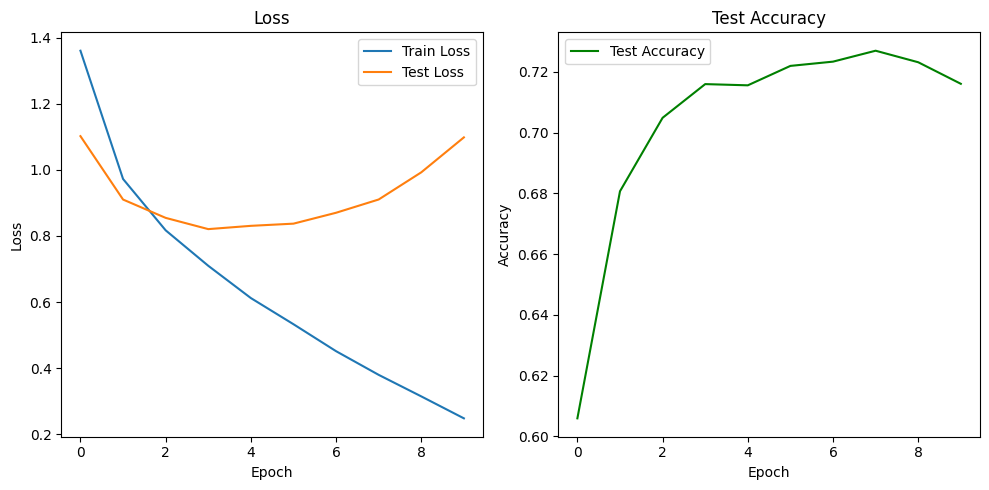

In [6]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(test_accuracies, label='Test Accuracy', color='green')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Test Accuracy')
plt.tight_layout()
plt.show()

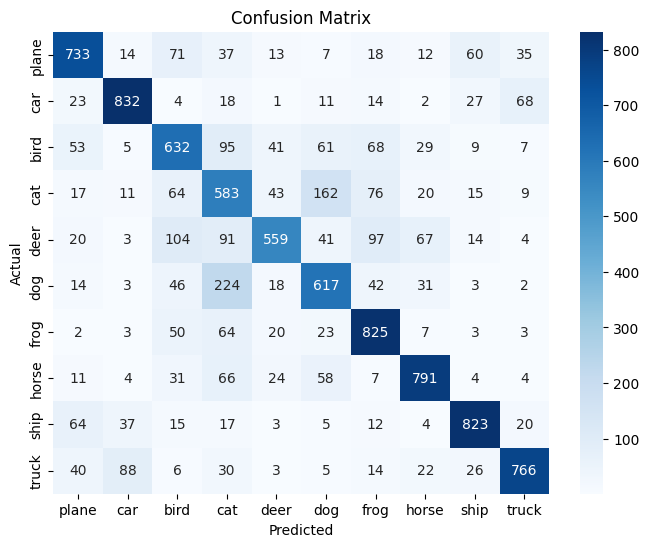

Model saved.


In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

# Save the trained model
torch.save(model.state_dict(), 'cnn_cifar10.pth')
print("Model saved.")

**Summary**

This CNN reached 72.7% test accuracy at its best epoch, far above the 10% random-guess baseline for 10 classes. Its main weakness is distinguishing cats from dogs (the largest single error in the confusion matrix), while it separates broad categories like vehicles from animals very reliably. The loss curve shows overfitting beginning around epoch 4–5, suggesting fewer epochs or added regularization could improve generalization. Limitations: a fairly small untuned architecture with no data augmentation.